In [30]:
from sklearn.datasets import load_boston
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import warnings
from IPython.display import display
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings(action='ignore')
np.set_printoptions(linewidth=300)
matplotlib.rcParams['figure.figsize'] = [16.0, 6.0]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.593761,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.596783,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.647423,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


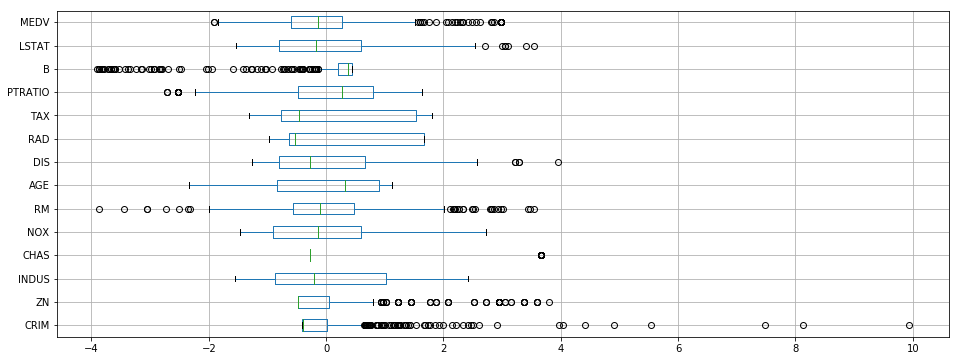

In [28]:
boston = load_boston()
df = pd.DataFrame(data=boston.data, columns=boston.feature_names)
df['MEDV'] = boston.target
df.sample(frac=1)
display(df.head())
display(df.describe())
df_cs = (df - df.mean())/df.std()
_=df_cs.boxplot(vert=False)

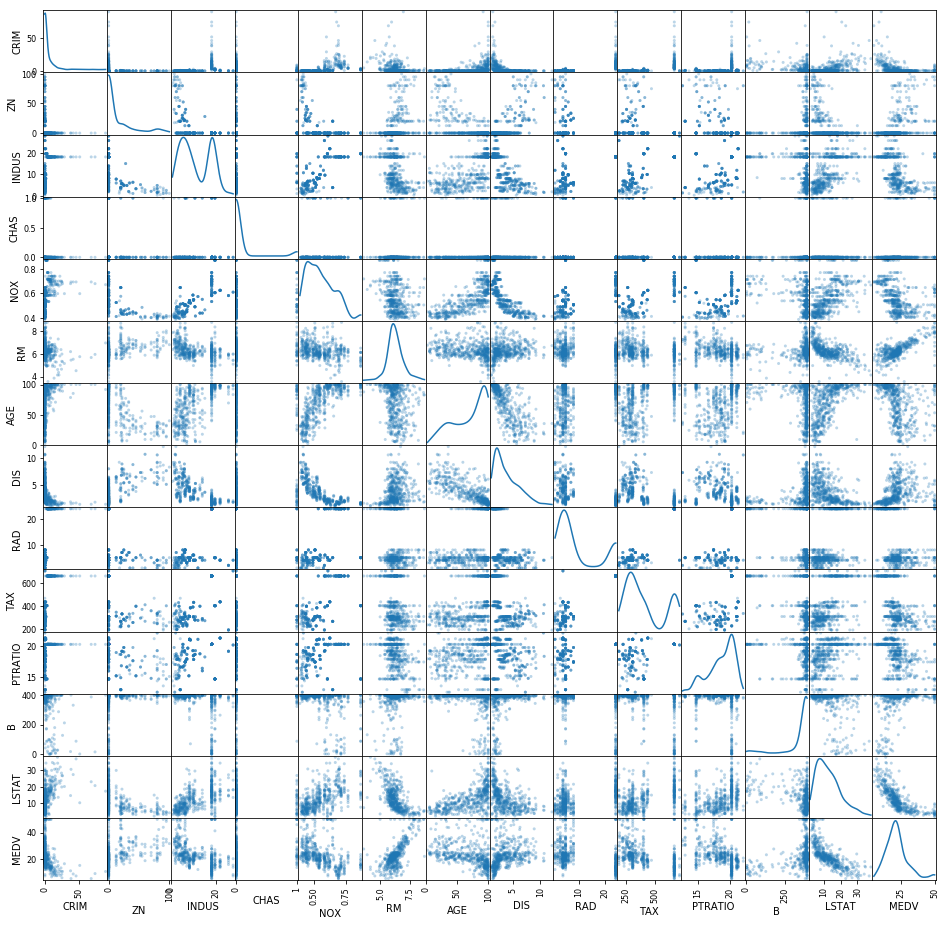

In [13]:
_ = pd.plotting.scatter_matrix(df, alpha = 0.3, figsize=(16, 16), diagonal = 'kde')

In [31]:
full_formula = "NOX ~ CRIM + ZN + INDUS + CHAS + RM + AGE + DIS + RAD + TAX + PTRATIO + B + LSTAT + MEDV"

naive_formula = "NOX ~ CRIM + INDUS + AGE + DIS + RAD + PTRATIO  + MEDV"
naive_model = smf.ols(naive_formula, data=df).fit()

formula = "NOX ~ CRIM + INDUS + AGE + DIS + I(DIS**2) + RAD + PTRATIO  + MEDV"
model = smf.ols(formula, data=df).fit()
print(formula)
display(model.summary())

NOX ~ CRIM + INDUS + AGE + DIS + I(DIS**2) + RAD + PTRATIO  + MEDV


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    NOX   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     257.0
Date:                Tue, 14 Nov 2017   Prob (F-statistic):          3.31e-171
Time:                        05:13:42   Log-Likelihood:                 787.10
No. Observations:                 506   AIC:                            -1556.
Df Residuals:                     497   BIC:                            -1518.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.9082      0.037     24.576      0.000       0.836       0.981
CRIM           -0.0013      0.000     -3.707      0.000      -0.002      -0.001
INDUS           0.0031      0.001      5.329      0.000       0.002       0.004
AGE             0.0005      0.000      3.971      0.000       0.000       0.001
DIS            -0.0646      0.006    -10.403      0.000      -0.077      -0.052
I(DIS ** 2)     0.0041      0.001      7.965      0.000       0.003       0.005
RAD             0.0034      0.000      8.377      0.000       0.003       0.004
PTRATIO        -0.0124      0.001     -9.372      0.000      -0.015      -0.010
MEDV           -0.0025      0.000     -7.553      0.000      -0.003      -0.002
==============================================================================
Omnibus:                       51.264   Durbin-Watson:                   0.495
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               68.458
Skew:                           0.759   Prob(JB):                     1.36e-15
Kurtosis:                       3.971   Cond. No.                     1.32e+03
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.32e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

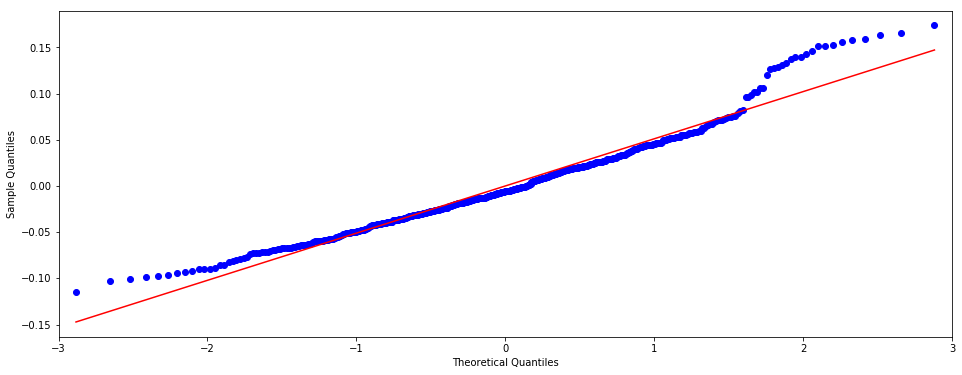

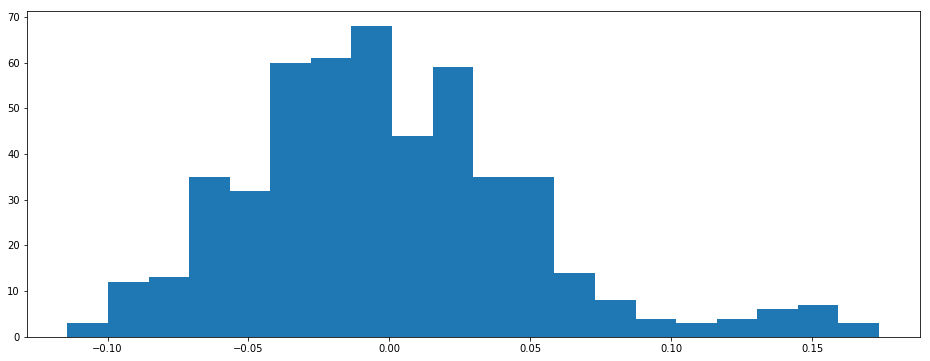

In [32]:
fig = sm.qqplot(model.resid, line='s')
plt.show()
_ = plt.hist(model.resid, bins=20, )

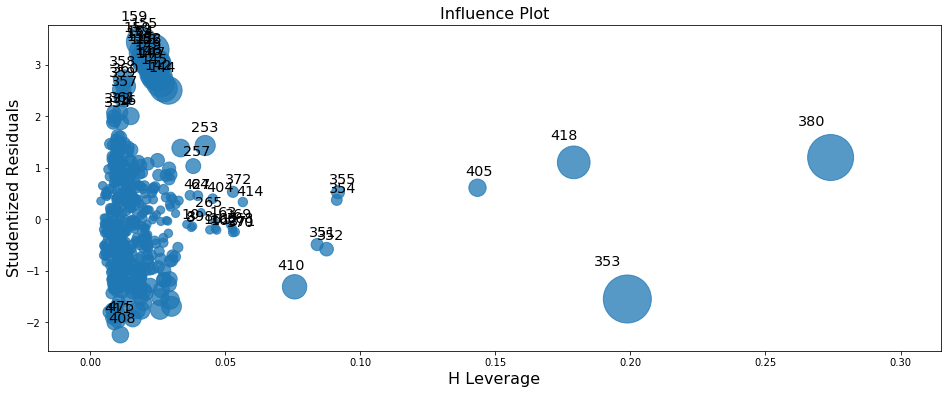

In [33]:
fig, ax = plt.subplots()
fig = sm.graphics.influence_plot(model, ax=ax, criterion="cooks")


In [34]:
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
CRIM,0.036504,1.0,13.744751,2.329703e-04
INDUS,0.075410,1.0,28.394346,1.503222e-07
AGE,0.041887,1.0,15.771843,8.201829e-05
DIS,0.287425,1.0,108.224484,4.589283e-23
I(DIS ** 2),0.168509,1.0,63.448795,1.130868e-14
RAD,0.186378,1.0,70.177049,5.582435e-16
PTRATIO,0.233295,1.0,87.842838,2.487395e-19
MEDV,0.151490,1.0,57.040643,2.062586e-13
Residual,1.319945,497.0,NaN,NaN


In [35]:
sm.stats.anova_lm(naive_model, model)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,498.0,1.488454,0.0,NaN,NaN,NaN
1,497.0,1.319945,1.0,0.168509,63.448795,1.130868e-14
